In [5]:
from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/MyDrive/predicting start point of genes"
!ls


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1CKDbRt7n4H09aDsCiEm_hFB4lNFevDhN/predicting start point of genes
extract_negative_windows.py			  negative_windows.fna
extract_protein_coding_starts.py		  negativewindows.ipynb
extract_windows.py				  new_negative_windows.fna
GCF_000001405.40_GRCh38.p14_feature_table.txt	  positive_windows.fna
GCF_000001405.40_GRCh38.p14_feature_table.txt.gz  protein_coding_starts.txt
GCF_000001405.40_GRCh38.p14_genomic.fna		  readme.txt
GCF_000001405.40_GRCh38.p14_genomic.fna.gz	  training_dataset.csv
make_training_dataset.py			  train_logreg_baseline.py
model_testing.ipynb


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv("training_dataset.csv")
print(df.shape)
print(df['label'].value_counts())

# One-hot encoding function
def one_hot(seq):
    map = {'A':[1,0,0,0],'C':[0,1,0,0],'G':[0,0,1,0],'T':[0,0,0,1]}
    seq = seq.upper()
    arr = np.zeros((len(seq),4),dtype=np.float32)
    for i,base in enumerate(seq):
        if base in map:
            arr[i] = map[base]
    return arr.flatten()

X = np.vstack(df['sequence'].apply(one_hot).values)
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Feature matrix:", X_train.shape)


(46602, 2)
label
0    23306
1    23296
Name: count, dtype: int64
Feature matrix: (37281, 400)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=2000, n_jobs=-1)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("LogReg Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr, digits=3))


LogReg Accuracy: 0.5588456174230233
              precision    recall  f1-score   support

           0      0.558     0.569     0.563      4662
           1      0.560     0.549     0.554      4659

    accuracy                          0.559      9321
   macro avg      0.559     0.559     0.559      9321
weighted avg      0.559     0.559     0.559      9321



In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("RandomForest Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf, digits=3))


RandomForest Accuracy: 0.5553052247612917
              precision    recall  f1-score   support

           0      0.550     0.614     0.580      4662
           1      0.562     0.497     0.528      4659

    accuracy                          0.555      9321
   macro avg      0.556     0.555     0.554      9321
weighted avg      0.556     0.555     0.554      9321



In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def show_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 100, 128)       │         9,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 33, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 33, 256)        │       360,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 33, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 438,145 (1.67 MB)

 Trainable params: 437,377 (1.67 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/10
466/466 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5311 - loss: 0.8305 - val_accuracy: 0.5553 - val_loss: 0.6835
Epoch 2/10
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5590 - loss: 0.6824 - val_accuracy: 0.5624 - val_loss: 0.6833
Epoch 3/10
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5666 - loss: 0.6757 - val_accuracy: 0.5529 - val_loss: 0.6844
Epoch 4/10
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5733 - loss: 0.6727 - val_accuracy: 0.5583 - val_loss: 0.6789
Epoch 5/10
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6015 - loss: 0.6580 - val_accuracy: 0.5552 - val_loss: 0.6814
Epoch 6/10
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6120 - loss: 0.6485 - val_accuracy: 0.5508 - val_loss: 0.6931
Epoch 7/10
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6566 - loss: 0.6130 - val_accuracy: 0.5483 - val_loss: 0.6980
Epoch 8/10
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7156 - loss: 0.5549 - val_accuracy: 0.

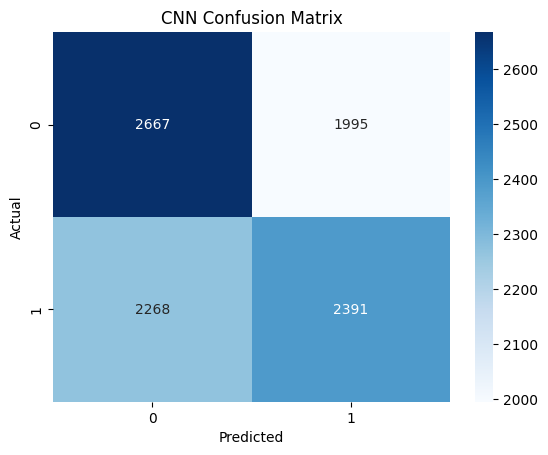

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

cnn = models.Sequential([
    Input(shape=(seq_len,4)),
    layers.Conv1D(128, kernel_size=19, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=3),

    layers.Conv1D(256, kernel_size=11, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalMaxPooling1D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(1, activation='sigmoid')
])

cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn.summary()

history = cnn.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

pred_cnn = (cnn.predict(X_test_cnn) > 0.5).astype(int)
print("CNN Accuracy:", accuracy_score(y_test, pred_cnn))
print(classification_report(y_test, pred_cnn, digits=3))
show_cm(y_test, pred_cnn, "CNN Confusion Matrix")


In [15]:
print("==== FINAL MODEL COMPARISON ====")
print("LogReg:", accuracy_score(y_test, pred_lr))
print("RandomForest:", accuracy_score(y_test, pred_rf))
print("CNN:", accuracy_score(y_test, pred_cnn))


==== FINAL MODEL COMPARISON ====
LogReg: 0.5588456174230233
RandomForest: 0.5553052247612917
CNN: 0.5426456388799485
